## Ćwiczenie 1: Kodowanie znaków

In [26]:
import pandas as pd
import requests
import sqlite3
import time
import os
import matplotlib.pyplot as plt

try:
    df_utf8 = pd.read_csv('pracownicy_utf8.csv')
    print("UTF-8 wczytany pomyślnie")
except Exception as e:
    print(f"UTF-8 błąd: {e}")

try:
    df_cp1250 = pd.read_csv('pracownicy_cp1250.csv')
    print("CP1250 wczytany pomyślnie")
except Exception as e:
    print(f"CP1250 błąd: {e}")

try:
    df_wrong = pd.read_csv('pracownicy_utf8.csv', encoding='cp1250')
    print("\nPrzykład Mojibake (UTF-8 czytany jako CP1250):")
    print(df_wrong.head(2))
except Exception as e:
    print(f"\nPróba wczytania UTF-8 jako CP1250 również kończy się błędem w tym środowisku:\n{e}")

df_fixed = pd.read_csv('pracownicy_cp1250.csv', encoding='cp1250')
df_fixed.to_csv('pracownicy_fixed_utf8.csv', index=False, encoding='utf-8')


UTF-8 wczytany pomyślnie
CP1250 błąd: 'utf-8' codec can't decode byte 0xa3 in position 48: invalid start byte

Próba wczytania UTF-8 jako CP1250 również kończy się błędem w tym środowisku:
'charmap' codec can't decode byte 0x81 in position 49: character maps to <undefined>


## Ćwiczenie 2: Brudny CSV

In [27]:
# 1. Proste wczytanie (wyrzuca błędy)
try:
    pd.read_csv('klienci.csv')
except Exception as e:
    print(f"Błąd przy prostym wczytaniu: {e}")

# 2. Naprawa pliku
df_klienci = pd.read_csv(
    'klienci.csv',
    encoding='cp1250',
    sep=';',
    decimal=',',
    na_values=['brak', '-', '?'],
    dtype={'kod_pocztowy': str}  # Zatrzymanie zer na początku kodu
)

# Naprawa formatu daty
df_klienci['data_rejestracji'] = pd.to_datetime(df_klienci['data_rejestracji'], format='%d.%m.%Y')

# 3. Sprawdzenie typów
print("\nTypy kolumn:")
print(df_klienci.dtypes)

# 4. Klienci z Łodzi i ich średni dochód
lodz = df_klienci[df_klienci['miasto'] == 'Łódź']
print(f"\nKlientów z Łodzi: {len(lodz)}")
print(f"Średni dochód: {lodz['dochod'].mean():.2f}")

# 5. Zapis do Parquet
df_klienci.to_parquet('klienci.parquet')
print(f"\nRozmiar CSV: {os.path.getsize('klienci.csv')} bajtów")
print(f"Rozmiar Parquet: {os.path.getsize('klienci.parquet')} bajtów")

Błąd przy prostym wczytaniu: 'utf-8' codec can't decode byte 0xb3 in position 98: invalid start byte

Typy kolumn:
id                           int64
kod_pocztowy                object
data_rejestracji    datetime64[ns]
miasto                      object
adres                       object
dochod                     float64
wiek                       float64
dtype: object

Klientów z Łodzi: 3
Średni dochód: 3783.58

Rozmiar CSV: 924 bajtów
Rozmiar Parquet: 5639 bajtów


## Ćwiczenie 3: Pobieranie danych z API NBP

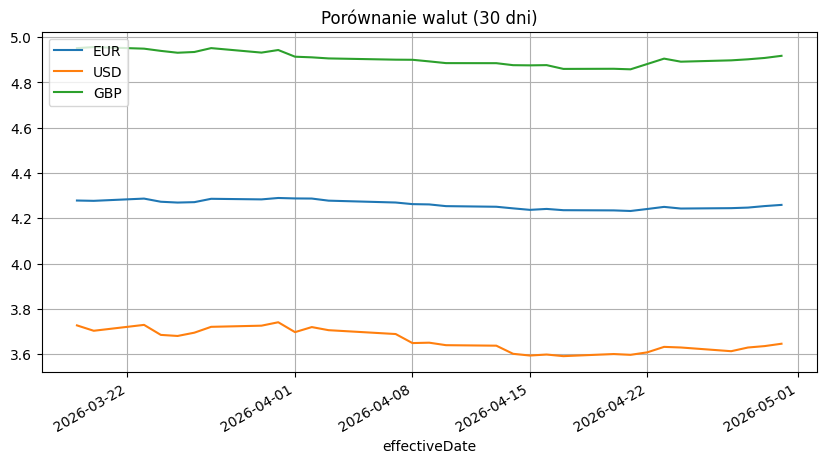


Najdroższe EUR w 2024 r. wynosiło: 4.4016 z dnia 2024-01-18


In [28]:
import requests
import matplotlib.pyplot as plt

# 1-3. Pobranie notowań EUR i DataFrame
response = requests.get("https://api.nbp.pl/api/exchangerates/rates/A/EUR/last/30/?format=json")
df_eur = pd.json_normalize(response.json()['rates'])

# 4. Wykres
df_eur['effectiveDate'] = pd.to_datetime(df_eur['effectiveDate'])
df_eur.set_index('effectiveDate', inplace=True)

# 5. Funkcja pomocnicza i połączenie danych
def get_rate(code):
    r = requests.get(f"https://api.nbp.pl/api/exchangerates/rates/A/{code}/last/30/?format=json").json()
    df = pd.json_normalize(r['rates'])
    df['effectiveDate'] = pd.to_datetime(df['effectiveDate'])
    return df.set_index('effectiveDate')['mid'].rename(code)

df_all = pd.concat([get_rate('EUR'), get_rate('USD'), get_rate('GBP')], axis=1)

# Wykres 3 walut
df_all.plot(title="Porównanie walut (30 dni)", figsize=(10, 5))
plt.grid()
plt.show()

# 6. Zapis
df_all.to_parquet('waluty_nbp.parquet')

# 7. Najdroższe EUR 2024
r_2024 = requests.get("https://api.nbp.pl/api/exchangerates/rates/A/EUR/2024-01-01/2024-12-31/?format=json").json()
df_2024 = pd.json_normalize(r_2024['rates'])
max_eur = df_2024.loc[df_2024['mid'].idxmax()]
print(f"\nNajdroższe EUR w 2024 r. wynosiło: {max_eur['mid']} z dnia {max_eur['effectiveDate']}")

## **4. Ćwiczenie 4: Benchmark formatów**



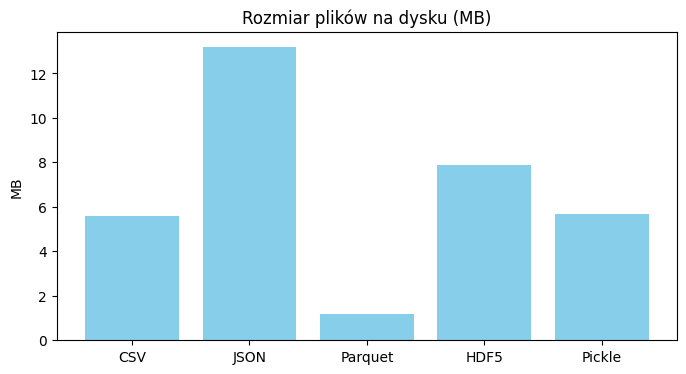

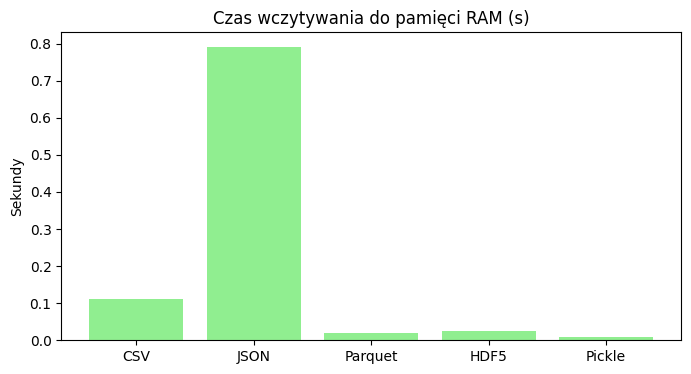

Czas wczytania wszystkich kolumn Parquet: 0.01942 s
Czas wczytania tylko 2 kolumn Parquet:  0.01227 s

WNIOSKI
Do długoterminowego przechowywania: PARQUET.
Do szybkich analiz: PICKLE lub PARQUET.
Dodatkowa zaleta Parquet: to format kolumnowy, więc pozwala wczytać tylko wybrane kolumny, co oszczędza RAM i czas.


In [29]:
import pandas as pd
import time
import os
import matplotlib.pyplot as plt

df = pd.read_csv('pomiary.csv')

df.to_json('pomiary.json')
df.to_parquet('pomiary.parquet')
df.to_hdf('pomiary.h5', key='data', mode='w')
df.to_pickle('pomiary.pkl')

formaty = ['CSV', 'JSON', 'Parquet', 'HDF5', 'Pickle']
pliki = ['pomiary.csv', 'pomiary.json', 'pomiary.parquet', 'pomiary.h5', 'pomiary.pkl']

rozmiary = [os.path.getsize(plik) / (1024 * 1024) for plik in pliki]

plt.figure(figsize=(8, 4))
plt.bar(formaty, rozmiary, color='skyblue')
plt.title('Rozmiar plików na dysku (MB)')
plt.ylabel('MB')
plt.show()

czasy = []

t0 = time.perf_counter(); pd.read_csv('pomiary.csv'); czasy.append(time.perf_counter() - t0)
t0 = time.perf_counter(); pd.read_json('pomiary.json'); czasy.append(time.perf_counter() - t0)
t0 = time.perf_counter(); pd.read_parquet('pomiary.parquet'); czasy.append(time.perf_counter() - t0)
t0 = time.perf_counter(); pd.read_hdf('pomiary.h5'); czasy.append(time.perf_counter() - t0)
t0 = time.perf_counter(); pd.read_pickle('pomiary.pkl'); czasy.append(time.perf_counter() - t0)

plt.figure(figsize=(8, 4))
plt.bar(formaty, czasy, color='lightgreen')
plt.title('Czas wczytywania do pamięci RAM (s)')
plt.ylabel('Sekundy')
plt.show()

czas_parquet_all = czasy[2]

t0 = time.perf_counter()
pd.read_parquet('pomiary.parquet', columns=['date', 'pm25'])
czas_parquet_2 = time.perf_counter() - t0

print(f"Czas wczytania wszystkich kolumn Parquet: {czas_parquet_all:.5f} s")
print(f"Czas wczytania tylko 2 kolumn Parquet:  {czas_parquet_2:.5f} s")

print("\nWNIOSKI")
print("Do długoterminowego przechowywania: PARQUET.")
print("Do szybkich analiz: PICKLE lub PARQUET.")
print("Dodatkowa zaleta Parquet: to format kolumnowy, więc pozwala wczytać tylko wybrane kolumny, co oszczędza RAM i czas.")



## Ćwiczenie 5: SQLite i pandas

In [31]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("sklep.db")
tabele = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print("Dostępne tabele:", tabele['name'].tolist(), "\n")

df_klienci = pd.read_sql("SELECT * FROM klienci", conn)
df_produkty = pd.read_sql("SELECT * FROM produkty", conn)
df_zamowienia = pd.read_sql("SELECT * FROM zamowienia", conn)

print(f"Rozmiary tabel - Klienci: {df_klienci.shape}, Produkty: {df_produkty.shape}, Zamówienia: {df_zamowienia.shape}\n")
print("Typy kolumn (klienci):\n", df_klienci.dtypes, "\n")

sql_top10 = """
SELECT k.imie, k.nazwisko, COUNT(z.id) as liczba_zamowien
FROM klienci k
JOIN zamowienia z ON k.id = z.klient_id
GROUP BY k.id
ORDER BY liczba_zamowien DESC
LIMIT 10
"""
print("Top 10 klientów (SQL):")
print(pd.read_sql(sql_top10, conn), "\n")

paczki = pd.read_sql("SELECT * FROM zamowienia", conn, chunksize=100)
pierwsza_paczka = next(paczki)
print(f"Wczytano testowo pierwszą porcję (chunk). Rozmiar: {len(pierwsza_paczka)} rekordów.\n")

sql_sprzedaz = """
SELECT p.kategoria, SUM(p.cena * z.ilosc) as wartosc_sprzedazy
FROM produkty p
JOIN zamowienia z ON p.id = z.produkt_id
GROUP BY p.kategoria
"""
print("Sprzedaż per kategoria (SQL):")
print(pd.read_sql(sql_sprzedaz, conn), "\n")

merged = df_zamowienia.merge(df_produkty, left_on='produkt_id', right_on='id')
merged['wartosc_sprzedazy'] = merged['ilosc'] * merged['cena']
wynik_pandas = merged.groupby('kategoria')['wartosc_sprzedazy'].sum().reset_index()

print("Sprzedaż per kategoria (Pandas):")
print(wynik_pandas, "\n")

print("WNIOSKI")
print("SQL: Krótszy, bardziej naturalny zapis")
print("Pandas wymaga więcej kroków w kodzie. W przypadku ogromnych tabel operacja merge w Pythonie może zająć mnóstwo pamięci.")

conn.close()

Dostępne tabele: ['klienci', 'produkty', 'zamowienia'] 

Rozmiary tabel - Klienci: (200, 6), Produkty: (15, 4), Zamówienia: (1000, 5)

Typy kolumn (klienci):
 id                   int64
imie                object
nazwisko            object
miasto              object
wiek                 int64
data_rejestracji    object
dtype: object 

Top 10 klientów (SQL):
      imie    nazwisko  liczba_zamowien
0    Piotr      Wójcik               10
1  Grażyna     Woźniak               10
2   Michał     Woźniak               10
3     Adam    Kamiński                9
4   Tomasz  Wiśniewski                9
5   Damian    Kowalski                9
6    Maria     Woźniak                9
7   Michał   Kozłowski                9
8    Filip   Kowalczyk                9
9   Bartek     Woźniak                9 

Wczytano testowo pierwszą porcję (chunk). Rozmiar: 100 rekordów.

Sprzedaż per kategoria (SQL):
     kategoria  wartosc_sprzedazy
0    Akcesoria            60495.0
1        Biuro            11625.0
